# Single-Stage Toy Objective

## What you will learn
How coupled plasma and coil terms can be optimized together using continuation.

## Codes used
Pure Python toy objective; optional JAX/SIMSOPT research extension.

## Run mode
This notebook uses RUN_MODE = "cached" by default. Allowed values are "tiny", "cached", and "research".

## Expected outputs
`05_single_stage_history.png` and `05_weight_continuation.png`.

## What this teaches

The object is a coupled objective: plasma and coil terms changing together under continuation.

## What this does not prove

It does not prove that the toy optimum is physically realizable or globally optimal.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "sos2026").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
print("Project root: repository root detected")

Project root: repository root detected


In [2]:
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    print("Colab detected. Keep RUN_MODE='cached' first; install requirements-colab.txt from the cloned repo if needed.")
else:
    print("Local runtime detected.")

Local runtime detected.


In [3]:
RUN_MODE = "cached"  # allowed: "tiny", "cached", "research"
print(f"RUN_MODE = {RUN_MODE}")

RUN_MODE = cached


In [4]:
import importlib
import json
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False})

from sos2026.paths import PROJECT_ROOT, DATA_DIR, CACHE_DIR, FIGURE_DIR, MOVIE_DIR, ensure_directories
ensure_directories()
print("Figures:", FIGURE_DIR.relative_to(PROJECT_ROOT))
print("Cached data:", CACHE_DIR.relative_to(PROJECT_ROOT))

Figures: assets/figures
Cached data: data/cached


## 1. Learning frame

This notebook is a deliberately small project: define one metric, produce one plot, expose one failure mode, and identify where a real code would enter.

In [5]:
from sos2026.plotting import savefig, caption

## 2. Load or generate the teaching data

Cached mode uses small arrays so the conceptual workflow is always available.

In [6]:
steps = np.arange(50)
J_plasma = 0.7*np.exp(-steps/10) + 0.05
J_flux = 1.0*np.exp(-steps/15) + 0.08
J_coil = 0.55*np.exp(-steps/25) + 0.12
history = pd.DataFrame({"step": steps, "J_plasma": J_plasma, "J_flux": J_flux, "J_coil": J_coil})
history.head()

,step,J_plasma,J_flux,J_coil
0,0,0.750000,1.080000,0.670000
1,1,0.683386,1.015507,0.648434
2,2,0.623112,0.955173,0.627714
3,3,0.568573,0.898731,0.607806
4,4,0.519224,0.845928,0.588679


## 3. Make the primary plot

Every plot has a one-sentence caption because students should know how to read it without guessing.

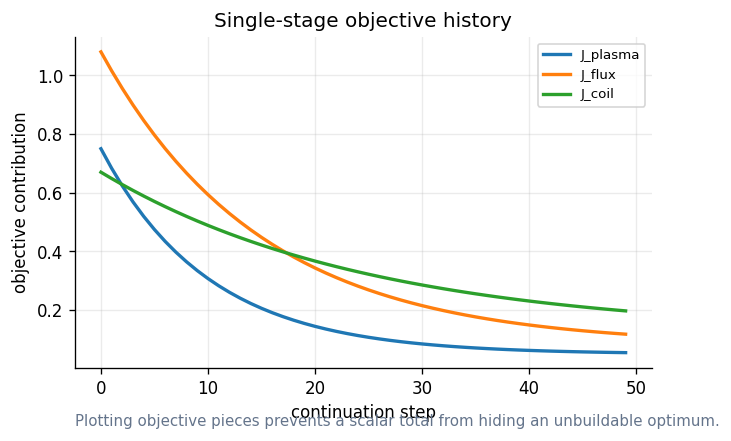

In [7]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
for col in ["J_plasma", "J_flux", "J_coil"]:
    ax.plot(history["step"], history[col], lw=2, label=col)
ax.set_xlabel("continuation step")
ax.set_ylabel("objective contribution")
ax.set_title("Single-stage objective history")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "Plotting objective pieces prevents a scalar total from hiding an unbuildable optimum.")
savefig(fig, "05_single_stage_history.png")
plt.show()

## 4. Probe the metric

A metric becomes useful for optimization only when we understand how it changes across design choices.

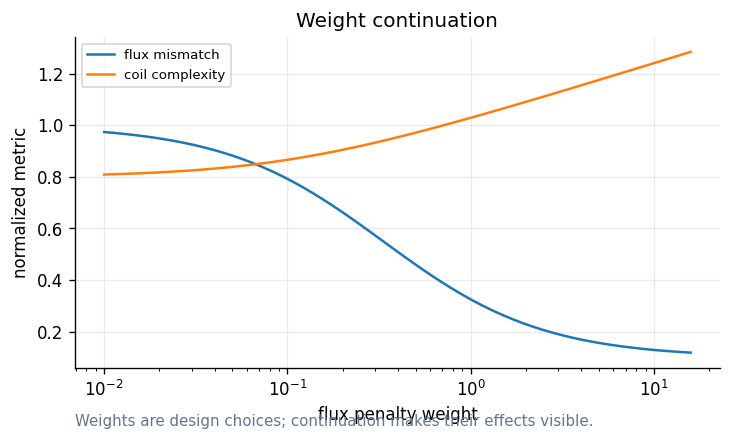

In [8]:
w = np.logspace(-2, 1.2, 60)
flux = 0.10 + 0.9/(1 + 3*w)
complexity = 0.8 + 0.22*np.log10(1 + 10*w)
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(w, flux, label="flux mismatch")
ax.plot(w, complexity, label="coil complexity")
ax.set_xscale("log")
ax.set_xlabel("flux penalty weight")
ax.set_ylabel("normalized metric")
ax.set_title("Weight continuation")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)
caption(ax, "Weights are design choices; continuation makes their effects visible.")
savefig(fig, "05_weight_continuation.png")
plt.show()

## 5. Interpret the design consequence

The table below translates the plot into an optimization decision.

In [9]:
terms = pd.DataFrame({
    "term": ["J_plasma", "J_flux", "J_coil", "J_separation", "J_curvature"],
    "protects": ["magnetic quality", "target surface", "buildability", "coil clearance", "manufacturing"],
    "failure_if_missing": ["poor confinement", "coils do not make the plasma", "wild coils", "collisions/access loss", "unbuildable bends"],
})
terms

,term,protects,failure_if_missing
0,J_plasma,magnetic quality,poor confinement
1,J_flux,target surface,coils do not make the plasma
2,J_coil,buildability,wild coils
3,J_separation,coil clearance,collisions/access loss
4,J_curvature,manufacturing,unbuildable bends


## 6. Failure mode

The cached plot is useful only if we say what it does not prove.

In [10]:
failure_mode = pd.DataFrame({
    "cached_mode_proves": ["workflow shape", "plot grammar", "where the metric enters"],
    "cached_mode_does_not_prove": ["validated physics", "final design ranking", "runtime scalability"],
})
failure_mode

,cached_mode_proves,cached_mode_does_not_prove
0,workflow shape,validated physics
1,plot grammar,final design ranking
2,where the metric enters,runtime scalability


## 7. Research-mode hook

Run this cell only after timing the package on the lecture machine.

In [11]:
if RUN_MODE == "research":
    print("Research path: replace toy terms with differentiable VMEC-JAX/SIMSOPT quantities.")
else:
    print("Cached mode: research package path skipped intentionally.")

Cached mode: research package path skipped intentionally.


## 8. Mini project handoff

Use this notebook during the lecture as the computational project slide points to: change one parameter, regenerate one plot, and explain one design tradeoff.

In [12]:
project_steps = pd.DataFrame({
    "step": [1, 2, 3, 4],
    "action": ["identify metric", "change one input", "regenerate plot", "state failure mode"],
})
project_steps

,step,action
0,1,identify metric
1,2,change one input
2,3,regenerate plot
3,4,state failure mode


<!-- SOS2026_EXTRA_CLASSROOM_EXAMPLE -->

## Additional classroom example

This final example adds a second view of the same lesson. The goal is to make the GitHub-rendered notebook useful even before a student runs it locally.

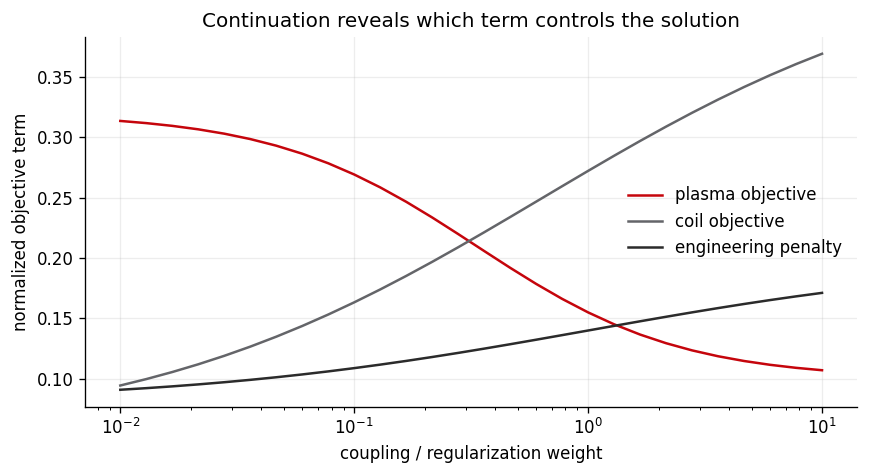

Caption: continuation starts with an easier problem and increases the coupling only after the design has a reasonable path.


In [13]:
weights = np.logspace(-2, 1, 28)
plasma_error = 0.10 + 0.22 / (1 + 3 * weights)
coil_error = 0.40 / (1 + 0.8 / np.sqrt(weights)) + 0.05
engineering_margin = 0.08 + 0.12 * np.sqrt(weights) / (1 + np.sqrt(weights))
fig, ax = plt.subplots(figsize=(8.3, 4.0))
ax.plot(weights, plasma_error, label="plasma objective", color="#c5050c")
ax.plot(weights, coil_error, label="coil objective", color="#646569")
ax.plot(weights, engineering_margin, label="engineering penalty", color="#2b2b2b")
ax.set_xscale("log")
ax.set_xlabel("coupling / regularization weight")
ax.set_ylabel("normalized objective term")
ax.set_title("Continuation reveals which term controls the solution")
ax.grid(alpha=0.22)
ax.legend(frameon=False)
plt.show()
print("Caption: continuation starts with an easier problem and increases the coupling only after the design has a reasonable path.")

## Output review prompt

Before using this notebook in class, check that the final plot has a clear title, readable axes, and a caption that states what design decision it supports.

## Try this
Change one scalar or one row in the cached data and regenerate the primary plot.

## Expected qualitative answer
The plot should move in a physically interpretable direction, but the cached result remains an educational proxy.

## Research extension
Replace the cached data source with the corresponding real package output after timing and API verification.